# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

### ✍️ Updates applied in this version (Beginner Tasks)
1. Corpus replaced with a custom paragraph
2. Embedding dimension increased: 32 → **64**
3. Epochs increased: 100 → **200**
4. Hidden units increased: 64 → **128**
5. Text generation length increased: 5 → **10** words

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [16]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 📥 Load Text Corpus
**Beginner Task 1 applied:** the corpus has been replaced with a custom paragraph.


In [17]:
corpus = '''
the ocean covers most of the earth and holds countless mysteries
deep beneath the waves strange creatures glow in the endless dark
sailors have always told stories about storms and hidden treasure
every wave carries a memory of distant shores and quiet harbors
explorers dream of mapping the unknown depths of the open sea
the ocean teaches patience power and the beauty of mystery
'''
print(corpus)


the ocean covers most of the earth and holds countless mysteries
deep beneath the waves strange creatures glow in the endless dark
sailors have always told stories about storms and hidden treasure
every wave carries a memory of distant shores and quiet harbors
explorers dream of mapping the unknown depths of the open sea
the ocean teaches patience power and the beauty of mystery



# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [18]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 50
X shape: (58, 10)
y shape: (58,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

**Beginner Tasks applied:** embedding dimension increased to **64**, hidden units increased to **128**, epochs increased to **200**.

In [19]:
rnn_model = Sequential([
    Embedding(total_words, 64),
    SimpleRNN(128),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=200, verbose=0)
print("Vanilla RNN training completed")

Vanilla RNN training completed


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

**Beginner Tasks applied:** embedding dimension increased to **64**, hidden units increased to **128**, epochs increased to **200**.

In [20]:
lstm_model = Sequential([
    Embedding(total_words, 64),
    LSTM(128),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=200, verbose=0)
print("LSTM training completed")

LSTM training completed


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

**Beginner Tasks applied:** embedding dimension increased to **64**, hidden units increased to **128**, epochs increased to **200**.

In [21]:
gru_model = Sequential([
    Embedding(total_words, 64),
    GRU(128),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=200, verbose=0)
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

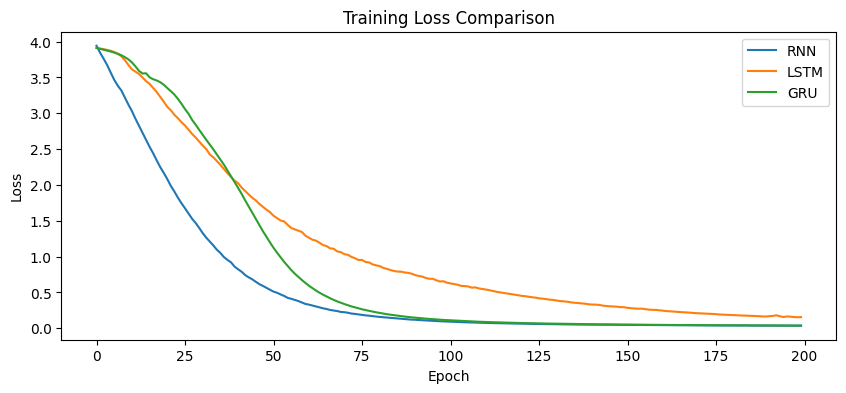

In [22]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

**Beginner Task applied:** default generation length increased from 5 to **10** words.

In [23]:
def generate_text(model, seed_text, next_words=10):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples
Generating **10 words** instead of the original 5.

In [24]:
print("RNN :", generate_text(rnn_model, "the ocean", 10))
print("LSTM:", generate_text(lstm_model, "the ocean", 10))
print("GRU :", generate_text(gru_model, "the ocean", 10))

RNN : the ocean teaches patience power and the beauty of mystery countless mysteries
LSTM: the ocean covers most of the earth and holds countless mysteries mysteries
GRU : the ocean teaches patience power and the beauty of mystery mystery mysteries


# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**
- With the beginner-task upgrades (bigger embeddings, more hidden units, longer training, longer generation), all three models get more capacity to learn from the corpus — a great hands-on way to see how each tweak affects results